# 📡 Bluetooth proximity dataset — EDA and preprocessing

Copenhagen Networks Study, `bt_symmetric.csv` (**5.47M rows**): `timestamp`,
`user_a`, `user_b`, `rssi`. This is the only dataset that already has real
cleaning logic in the codebase — `src/features/preprocessing.py::clean_bluetooth_data`
filters sentinels, applies the RSSI threshold, and slots time. This notebook
runs the same **(1) duplicates → (2) missing data → (3) outliers → (4)
scaling** checklist as the other per-dataset notebooks, at the raw-file
level, to verify (not just assume) that pipeline's decisions are justified,
and to add the reporting/flagging steps it doesn't currently do (duplicate
check, IQR-based RSSI outlier flag, a scaled RSSI column).

Per `bt_symmetric.README` / the project README's Bluetooth rules:

- `user_b == -1` and `rssi == 0` → **empty scan** (sentinel, not missing).
- `user_b == -2` → **one or more devices outside the study** (sentinel, not
  a person, not missing).
- `user_a >= 0` and `user_b >= 0` → a candidate participant-to-participant
  contact.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.config import load_config
from src.data.io import load_bluetooth_data, write_processed_data
from src.features import eda

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "7267433" / "bt_symmetric.csv"
config = load_config(str(PROJECT_ROOT / "config" / "config.yaml"))
%matplotlib inline

In [2]:
data = load_bluetooth_data(RAW_PATH)
print(data.shape)
data.head()

(5474289, 4)


,timestamp,user_a,user_b,rssi
0,0,0,-1,0
1,0,1,-1,0
2,0,2,-1,0
3,0,3,-2,-88
4,0,5,-1,0


## (1) Duplicates

At 5.47M rows, an exact duplicate scan record would most likely come from a
logging artifact (the same scan written twice), not two genuinely distinct
events.

In [3]:
eda.duplicate_report(data)

{'n_rows': 5474289, 'n_duplicate_rows': 0, 'pct_duplicate_rows': 0.0}

**Decision:** `0` exact duplicate rows — nothing to drop. Kept as an
explicit check rather than an assumption, since a dataset this large is
exactly where a silent duplication bug would be easy to miss.

## (2) Missing data

`clean_bluetooth_data` coerces every column to numeric and drops rows that
fail — but nobody had checked *how many rows that actually affects* for
this file. Verify it directly, then separately account for the Bluetooth
sentinels, which are coded categories, not missing values.

In [4]:
coerced = data.apply(pd.to_numeric, errors="coerce")
n_failed_coercion = int(coerced.isna().any(axis=1).sum())
n_failed_coercion, round(100 * n_failed_coercion / len(data), 6)

(0, 0.0)

**Decision:** `0` rows fail numeric coercion in this raw file — the
existing `dropna()` in `clean_bluetooth_data` is a defensive no-op here, not
silently discarding real data. Worth keeping (a future data refresh could
introduce bad rows), but it isn't hiding anything today.

In [5]:
is_empty_scan = (coerced["user_b"] == -1) & (coerced["rssi"] == 0)
is_external_device = coerced["user_b"] == -2
is_valid_contact = (coerced["user_a"] >= 0) & (coerced["user_b"] >= 0)
unexpected = ~(is_empty_scan | is_external_device | is_valid_contact)

sentinel_summary = pd.Series(
    {
        "empty_scan (user_b=-1)": int(is_empty_scan.sum()),
        "external_device (user_b=-2)": int(is_external_device.sum()),
        "valid_contact_candidate (user_a,user_b>=0)": int(is_valid_contact.sum()),
        "unexpected": int(unexpected.sum()),
    }
)
sentinel_summary, (100 * sentinel_summary / len(data)).round(2)

(empty_scan (user_b=-1)                        2220136
 external_device (user_b=-2)                    827874
 valid_contact_candidate (user_a,user_b>=0)    2426279
 unexpected                                          0
 dtype: int64,
 empty_scan (user_b=-1)                        40.56
 external_device (user_b=-2)                   15.12
 valid_contact_candidate (user_a,user_b>=0)    44.32
 unexpected                                     0.00
 dtype: float64)

**Decision:** every row falls cleanly into one of the three
documented categories (`0` unexpected rows) — ~40.6% empty scans, ~15.1%
external-device detections, ~44.3% candidate participant contacts. None of
these are missing data to impute; they are meaningful categorical codes,
already handled correctly by `clean_bluetooth_data`'s sentinel filter.

In [6]:
valid_contacts = coerced[is_valid_contact]
rssi_sign_violation = valid_contacts["rssi"] >= 0
int(rssi_sign_violation.sum())

4

**Decision:** a tiny number of rows (4 out of 2.43M candidate
contacts) have `user_a, user_b >= 0` but `rssi >= 0`, violating the
project's documented rule that a real contact has negative-dBm RSSI. This
is noise, not a value to correct — `clean_bluetooth_data`'s existing
`rssi < 0` filter already excludes these 4 rows from `contacts.parquet`;
this audit confirms that filter is doing real (if small) work.

## (3) Outliers

RSSI is the one continuous measurement here. Compute IQR bounds only on
**real candidate contacts with valid negative RSSI** — sentinel rows
(`rssi == 0` for empty scans) would otherwise distort the quartiles, the
same reasoning used for `duration` in `eda_calls.ipynb`.

In [7]:
real_contacts = valid_contacts[valid_contacts["rssi"] < 0]
outlier_bounds = eda.outlier_report_iqr(real_contacts, "rssi")
outlier_bounds

{'column': 'rssi',
 'q1': -92.0,
 'q3': -79.0,
 'iqr': 13.0,
 'lower_bound': -111.5,
 'upper_bound': -59.5,
 'n_outliers': 51295,
 'pct_outliers': 2.1141}

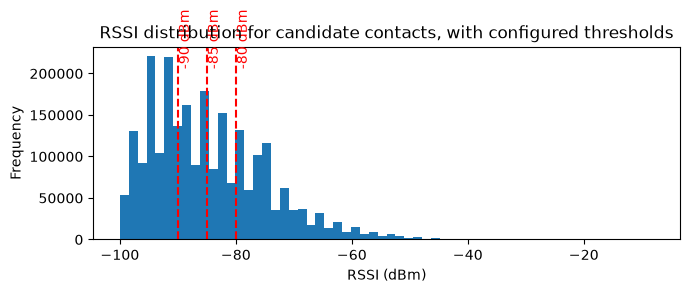

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
real_contacts["rssi"].plot(kind="hist", bins=60, ax=ax)
for threshold in config["bluetooth_parameters"]["rssi_thresholds"]:
    ax.axvline(threshold, linestyle="--", color="red")
    ax.text(threshold, ax.get_ylim()[1] * 0.9, f"{threshold} dBm", rotation=90, color="red")
ax.set_xlabel("RSSI (dBm)")
ax.set_title("RSSI distribution for candidate contacts, with configured thresholds")
fig.tight_layout()

**Decision:** ~2.1% of candidate contacts are IQR outliers, and all of
them are on the **strong-signal** side (RSSI above about -59.5 dBm, i.e.
phones very close together) — the weak-signal side never reaches the lower
IQR bound at all. These are flagged, not dropped: a very strong proximity
reading is physically plausible (two phones right next to each other), not
sensor error. The domain-specific decision that actually controls which
contacts get used downstream is the RSSI-threshold sweep already defined in
`config.yaml` (`-80`, `-85`, `-90` dBm), shown above against the real
distribution — not a generic IQR cut.

In [9]:
outlier_flags = eda.flag_outliers_iqr(real_contacts, "rssi")[["rssi_outlier"]]
real_contacts = real_contacts.join(outlier_flags)
real_contacts["rssi_outlier"].value_counts()

rssi_outlier
False    2374980
True       51295
Name: count, dtype: int64

## (4) Scaling

Scale `rssi` (a magnitude) for candidate contacts only — sentinel rows
(`rssi == 0`, meaning "no scan", not "zero signal") are excluded so they
cannot pull the mean/variance away from real measurements. `timestamp`,
`user_a`, `user_b` are never scaled: a temporal key and anonymous
categorical participant IDs, not measurements — consistent with every other
notebook in this series and with the project README's explicit rule that
participant IDs are never treated as numerical measurements.

In [10]:
scaled_contacts, rssi_scaler = eda.scale_numeric_columns(real_contacts, ["rssi"], method="robust")
scaled_contacts[["timestamp", "user_a", "user_b", "rssi", "rssi_outlier", "rssi_scaled"]].head()

,timestamp,user_a,user_b,rssi,rssi_outlier,rssi_scaled
15,0,21,20,-73,False,1.000000
34,0,47,19,-86,False,0.000000
36,0,49,48,-62,False,1.846154
51,0,69,44,-87,False,-0.076923
66,0,90,64,-96,False,-0.769231


## (5)/(6) Balancing & encoding — not applicable here

`is_empty_scan`/`is_external_device`/`is_valid_contact` are descriptive
sentinel flags, not a classification target, so there is nothing to
balance. `user_a`/`user_b` are anonymous **nominal** participant IDs — no
inherent order, so ordinal encoding isn't applied to them.

## Result

Assemble the prepared row-level dataframe: every raw row is kept and
labeled with its sentinel category, and candidate contacts additionally get
their outlier flag and scaled RSSI.

In [11]:
data["is_empty_scan"] = is_empty_scan
data["is_external_device"] = is_external_device
data["is_valid_contact"] = is_valid_contact
data["rssi_outlier"] = pd.NA
data["rssi_scaled"] = pd.NA
data.loc[scaled_contacts.index, "rssi_outlier"] = scaled_contacts["rssi_outlier"]
data.loc[scaled_contacts.index, "rssi_scaled"] = scaled_contacts["rssi_scaled"]
data.head()

,timestamp,user_a,user_b,rssi,is_empty_scan,is_external_device,is_valid_contact,rssi_outlier,rssi_scaled
0,0,0,-1,0,True,False,False,<NA>,<NA>
1,0,1,-1,0,True,False,False,<NA>,<NA>
2,0,2,-1,0,True,False,False,<NA>,<NA>
3,0,3,-2,-88,False,True,False,<NA>,<NA>
4,0,5,-1,0,True,False,False,<NA>,<NA>


`data` is the prepared dataframe for `bt_symmetric.csv`:

- 0 duplicate rows, 0 rows failing numeric coercion (verified, not assumed).
- Sentinel categories (`is_empty_scan`, `is_external_device`,
  `is_valid_contact`) made explicit as boolean columns instead of relying on
  readers to remember the `-1`/`-2` codes.
- 4 rows where a candidate contact has non-negative RSSI identified as
  noise (excluded from the pipeline's `contacts.parquet` already).
- `rssi_outlier` flags unusually strong-signal contacts without dropping
  them; `rssi_scaled` holds the median/IQR-scaled (`RobustScaler`) RSSI for
  candidate contacts — chosen because the flagged strong-signal outliers
  are kept, not dropped.

This is a row-level EDA artifact, not a replacement for the pipeline: it is
saved separately from `contacts.parquet`/`coverage.parquet`
(`clean_bluetooth_data`'s outputs), which remain the actual inputs to
gathering extraction.

In [12]:
output_path = write_processed_data(
    data, PROJECT_ROOT / "data" / "processed", "bt_symmetric_prepared.parquet"
)
output_path

PosixPath('/home/johnny/master_uu/UU-DataMining-2026/data/processed/bt_symmetric_prepared.parquet')